<a href="https://colab.research.google.com/github/SpiderFang/Ecommerce_customer_behavior_analysis/blob/main/ecommerce_customer_behavior_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**模擬「電商客戶行為分析」**

第一步：環境準備與數據模擬

使用 pandas 處理數據，並用 scipy 做統計檢定。

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

# 模擬用的數據：客戶購買金額 (A/B Test 實驗組與對照組)
np.random.seed(42)
data = pd.DataFrame({
    'group': ['A'] * 100 + ['B'] * 100,
    'spend': np.concatenate([np.random.normal(100, 20, 100), np.random.normal(115, 25, 100)]),
    'age': np.random.randint(20, 60, 200),
    'clicks': np.random.poisson(10, 200)
})

print("數據前五筆：")
display(data.head())
print("數據後五筆：")
display(data.tail())

數據前五筆：


,group,spend,age,clicks
0,A,109.934283,21,8
1,A,97.234714,45,6
2,A,112.953771,36,11
3,A,130.460597,59,5
4,A,95.316933,52,12


數據後五筆：


,group,spend,age,clicks
195,B,124.632934,50,10
196,B,92.903564,24,8
197,B,118.843128,54,5
198,B,116.455218,42,12
199,B,86.425743,48,12


1. pd.DataFrame({...}): 這是創建 Pandas DataFrame 的標準方式。它接受一個字典作為參數，字典的鍵會成為 DataFrame 的列名，而字典的值則會成為對應列的數據。

2. 'group': ['A'] * 100 + ['B'] * 100:

這行定義了 group 列。它創建了一個包含100個 'A' 和100個 'B' 的列表。
['A'] * 100 產生 ['A', 'A', ..., 'A'] (100個)。
['B'] * 100 產生 ['B', 'B', ..., 'B'] (100個)。
+ 運算符將這兩個列表連接起來，形成一個包含200個元素的列表，前100個是 'A'，後100個是 'B'。這通常用於模擬 A/B 測試中的兩個實驗組或對照組。

3. 'spend': np.concatenate([np.random.normal(100, 20, 100), np.random.normal(115, 25, 100)]):

這行定義了 spend（消費金額）列。
np.random.normal(100, 20, 100): 使用 NumPy 的 normal 函數生成100個隨機數，這些數服從平均值為100、標準差為20的常態分佈。這模擬了 Group A 客戶的消費金額。
np.random.normal(115, 25, 100): 同樣生成100個隨機數，但這次服從平均值為115、標準差為25的常態分佈。這模擬了 Group B 客戶的消費金額。請注意，Group B 的平均消費金額和波動性都略高於 Group A。
np.concatenate([...]): 將這兩組100個隨機數連接起來，形成一個總共200個元素的單一 NumPy 陣列。這個陣列的數據會依次對應 Group A 和 Group B 的消費金額。

4. 'age': np.random.randint(20, 60, 200):

這行定義了 age（年齡）列。
np.random.randint(20, 60, 200): 生成200個介於20（包含）到60（不包含）之間的隨機整數，模擬200位客戶的年齡。

5. 'clicks': np.random.poisson(10, 200):

這行定義了 clicks（點擊次數）列。
np.random.poisson(10, 200): 生成200個服從參數 λ (lambda) 為10的卜瓦松分佈的隨機整數。卜瓦松分佈常用於模擬在固定時間或空間內稀有事件發生的次數，這裡用於模擬客戶的點擊次數。平均點擊次數為10。

總結來說，這段程式碼創建了一個包含200行數據的模擬數據集，每行代表一個客戶，有其所屬的群組 (group)、消費金額 (spend)、年齡 (age) 和點擊次數 (clicks)。這個數據集通常用於進行統計分析或機器學習模型的測試，例如 A/B 測試分析或預測消費金額的迴歸模型。


第二步：描述性統計, 了解數據分佈

分組描述性統計：


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,100.0,97.923070,18.163369,47.605098,87.981887,97.460874,108.119041,137.045564
B,100.0,115.557615,23.841724,67.030720,94.858487,117.102679,128.454261,183.004229


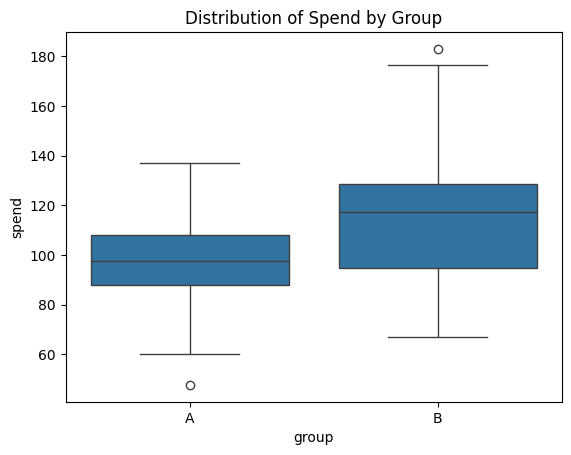

In [2]:
# 快速統計摘要
desc = data.groupby('group')['spend'].describe()
print("分組描述性統計：")
display(desc)

# 視覺化分佈
sns.boxplot(x='group', y='spend', data=data)
plt.title('Distribution of Spend by Group')
plt.show()


第三步：推論統計 - A/B Test 假設檢定

核心: 例如判斷新方案（B組）是否顯著優於舊方案（A組）。

In [7]:
group_a = data[data['group'] == 'A']['spend']
group_b = data[data['group'] == 'B']['spend']

# 進行獨立樣本 t 檢定, ttest_ind() 函數用於比較兩個獨立樣本的平均值。
t_stat, p_val = stats.ttest_ind(group_a, group_b)

# t 統計量衡量了兩個組別平均值差異的大小，相對於樣本數據中的變異性。t 統計量的絕對值越大，表示兩個組別之間的差異越顯著。
print(f"t 統計量: {t_stat:.4f}")
# p-value 是統計檢定中最重要的指標之一。它表示在「虛無假設」成立的情況下（即 Group A 和 Group B 的真實平均消費金額沒有差異），觀察到目前或更極端差異的機率。一般來說，p 值越小，拒絕虛無假設的證據就越強。
print(f"p-value: {p_val:.4f}")

# 根據 p 值做出統計結論。0.05 是常用的「顯著水準」（或稱為 alpha 值）。
if p_val < 0.05:
    print("結論：在 95% 信心水準下，兩組消費金額有顯著差異（拒絕虛無假設）。")
else:
    print("結論：無顯著差異。")

# 如果 p_val 小於 0.05：我們就「拒絕虛無假設」。這意味著在 95% 的信心水準下，我們有足夠的統計證據認為 Group A 和 Group B 的平均消費金額之間存在顯著差異。這通常表示實驗組（B）對消費金額產生了統計上可觀察到的影響。
# 如果 p_val 大於或等於 0.05：我們就「未能拒絕虛無假設」。這意味著在目前的證據下，我們沒有足夠的統計證據來證明 Group A 和 Group B 的平均消費金額之間存在顯著差異，或者說觀察到的差異可能是由於隨機波動造成的。

t 統計量: -5.8836
p-value: 0.0000
結論：在 95% 信心水準下，兩組消費金額有顯著差異（拒絕虛無假設）。


第四步：相關性與迴歸分析, 理解變數之間的關係

In [8]:
# 建立簡易線性迴歸「Ordinary Least Squares」（普通最小平方法）：用「點擊次數」預測「消費金額」

# 在迴歸分析中，X 通常代表自變數（或稱獨立變數、預測變數），也就是我們用來預測或解釋另一個變數的因素。在這裡，我們假設點擊次數會影響消費金額。
X = data['clicks']
# 在迴歸分析中，y 通常代表應變數（或稱依賴變數、目標變數），也就是我們希望被預測或解釋的變數。在這裡，我們希望預測或解釋客戶的消費金額。
y = data['spend']
# 加入截距項, statsmodels 的線性迴歸模型預設不會自動包含截距項（intercept）。截距項在迴歸模型中代表當所有自變數都為 0 時，應變數的預測值。
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.697
Date:                Fri, 17 Apr 2026   Prob (F-statistic):              0.102
Time:                        14:03:29   Log-Likelihood:                -908.28
No. Observations:                 200   AIC:                             1821.
Df Residuals:                     198   BIC:                             1827.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        115.1898      5.392     21.362      0.0

**統計報告解釋**

這份統計報告（OLS Regression Results）是對您建立的線性迴歸模型進行擬合後得到的詳細結果。這個模型試圖用「點擊次數 (clicks)」來預測「消費金額 (spend)」。

以下是報告中的一些主要指標及其解釋：
1. 模型摘要 (Overall Model Fit)：

Dep. Variable (應變數): spend (消費金
額) - 這是您模型試圖預測或解釋的變數。

Model: OLS - 表示您使用了普通最小平方法 (Ordinary Least Squares) 迴歸。

R-squared (R平方): 0.013
這是一個非常重要的指標，表示自變數 clicks 能解釋應變數 spend 變異的百分比。0.013 表示只有 1.3% 的消費金額變異可以被點擊次數來解釋。這是一個非常低的值，說明這個模型對消費金額的解釋能力非常弱。

Adj. R-squared (調整R平方): 0.008
調整R平方在模型中包含多個自變數時更常用，它會根據模型中自變數的數量進行調整。在這裡，因為只有一個自變數，它的值與R平方相近，同樣顯示解釋能力很弱。

F-statistic (F統計量): 2.697
這個統計量用來檢定整個迴歸模型是否顯著。它檢定所有自變數（在這裡只有 clicks）是否至少有一個對應變數有顯著影響。

Prob (F-statistic) (F統計量的P值): 0.102
這是 F 統計量對應的 p 值。由於 0.102 大於常用的顯著水準 0.05，這表示在 95% 的信心水準下，我們無法拒絕虛無假設，即這個模型整體上對消費金額沒有顯著的預測能力。簡單來說，點擊次數在統計上並不能有效預測消費金額。

2. 係數與顯著性 (Coefficients and Significance)：

const (截距項): 115.1898
coef (係數): 115.1898。這表示當 clicks 為 0 時，預測的平均消費金額約為 115.19。
P>|t| (p 值): 0.000。由於 0.000 小於 0.05，截距項是統計顯著的。

clicks (點擊次數):
coef (係數): -0.8994。這表示每增加一次點擊，預計消費金額會減少約 0.90 個單位（雖然這個值很小）。
std err (標準誤): 0.548。係數的標準誤，用於計算 t 值和 p 值。
t (t 統計量): -1.642。這個值衡量係數與 0 的偏差程度。
P>|t| (p 值): 0.102。由於 0.102 大於 0.05，這表示 clicks 這個自變數在統計上並不顯著。換句話說，僅憑當前的數據，我們無法證明點擊次數對消費金額有統計上顯著的線性影響。
[0.025 0.975] (95% 信賴區間): [-1.979, 0.181]。這個區間包含了 0，也再次說明 clicks 係數不顯著。

結論：

根據這份統計報告，您的模型（使用點擊次數預測消費金額）的整體擬合度非常低（R-squared 很小），並且 F 統計量的 p 值和 clicks 變數自身的 p 值都大於 0.05。這強烈表明，在這個數據集上，點擊次數與消費金額之間沒有統計上顯著的線性關係。這可能意味著點擊次數並不是影響消費金額的主要因素，或者兩者之間的關係不是簡單的線性關係，又或者您的數據中存在其他更重要的影響因素沒有被納入模型。


第五步：分析 `age` 和 `spend` 之間的相關性

年齡 (age) 和消費金額 (spend) 之間的皮爾遜相關係數為: -0.0921


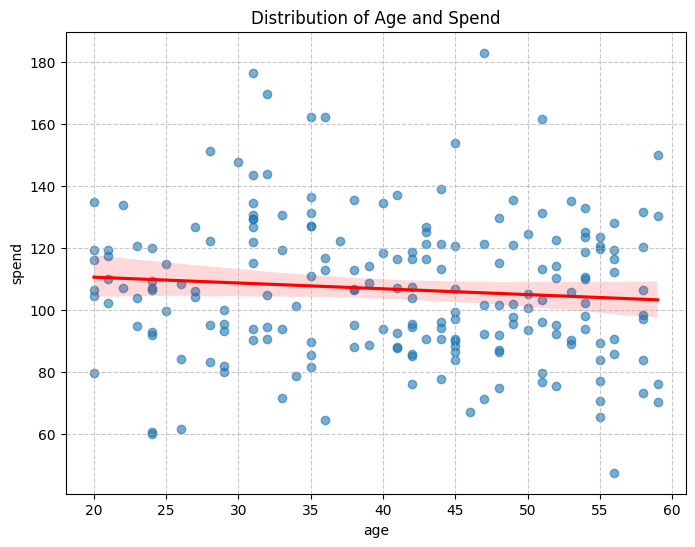

In [6]:
correlation = data['age'].corr(data['spend'])
print(f"年齡 (age) 和消費金額 (spend) 之間的皮爾遜相關係數為: {correlation:.4f}")

plt.figure(figsize=(8, 6))
sns.regplot(x='age', y='spend', data=data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Distribution of Age and Spend')
plt.xlabel('age')
plt.ylabel('spend')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

皮爾遜相關係數（Pearson correlation coefficient），通常用符號 r 表示，是一種衡量兩個變數之間線性關係強度與方向的統計指標。

核心概念：

數值範圍：它的值介於 -1 到 +1 之間。

+1：表示兩個變數之間存在完美正向線性關係。當一個變數增加時，另一個變數也以固定的比例增加。

-1：表示兩個變數之間存在完美負向線性關係。當一個變數增加時，另一個變數以固定的比例減少。

0：表示兩個變數之間沒有線性關係。這並不代表兩個變數完全沒有關係，只是沒有線性的關係（例如，它們可能存在曲線關係）。

強度：絕對值越接近 1，表示線性關係越強；絕對值越接近 0，表示線性關係越弱。

方向：正值表示同向變化（一個增加另一個也增加），負值表示反向變化（一個增加另一個減少）。

適用情境：

皮爾遜相關係數主要用於分析連續型資料之間的線性關係。例如，研究身高與體重、學習時間與考試成績、廣告投入與銷售額等。

重要注意事項：

1. 只能衡量線性關係：如果兩個變數之間存在非線性關係（例如拋物線關係），皮爾遜相關係數可能會接近 0，但實際上它們之間仍有很強的關係。

2. 不代表因果關係：相關不等於因果。即使兩個變數高度相關，也無法直接推斷其中一個是另一個的原因。

3. 對異常值敏感：異常值（outliers）可能會顯著影響相關係數的值。

簡而言之，它告訴我們兩個變數在多大程度上一起增長或減少，以及這種趨勢是正向的還是負向的。